# 2 Preprocessing

In this notebook, we will work over what we saw on `1_eda.ipynb` in order to correctly preprocess our data. As a summary, we will be addressing the following issues:
- Most columns that reflect some count of number of shares contain outliers.
- Additionally, ignoring the outliers, the distributions are highly skeewed.
- We have a lot of collinearity in our dataset.

We start by importing all libraries that we will use, both for preprocessing and plotting.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler

We read the original dataset.

In [2]:
df = pd.read_csv('../data/OnlineNewsPopularity.csv')

## 2.1 Initial Generic Preprocessing
To begin with, even though we know we do not have duplicates nor NAs, we provide the code to get rid of them.

In [3]:
print(f"Dataset shape before dropping duplicates and nulls: {df.shape}")
df.drop_duplicates(inplace=True)
df.dropna(inplace=True)
print(f"Dataset shape after dropping duplicates and nulls: {df.shape}")

Dataset shape before dropping duplicates and nulls: (39644, 61)
Dataset shape after dropping duplicates and nulls: (39644, 61)


Next, we will drop the metadata columns `url` and `timedelta` since we will not be using them for our predictions.

In [4]:
df.drop(columns=['url', ' timedelta'], inplace=True)
print(f"Dataset shape after dropping metadata columns: {df.shape}")

Dataset shape after dropping metadata columns: (39644, 59)


We also noticed that all columns come with a leading space character. We will strip them of it.

In [5]:
print(f"Column names with leading space: '{df.columns[1]}'")
df.columns = df.columns.str.strip()
print(f"Column names after stripping leading spaces: '{df.columns[1]}'")

Column names with leading space: ' n_tokens_content'
Column names after stripping leading spaces: 'n_tokens_content'


Next, we will define the different feature groups we have in our dataset. These will be `NUMERICAL_FEATURES`, `CATEGORICAL_FEATURES` and `TARGET`. This will be useful when we want to perform some method to an specific data type subset of the features.

In [6]:
NUMERICAL_FEATURES = [
    "n_tokens_title",
    "n_tokens_content",
    "n_unique_tokens",
    "n_non_stop_words",
    "n_non_stop_unique_tokens",
    "num_hrefs",
    "num_self_hrefs",
    "num_imgs",
    "num_videos",
    "average_token_length",
    "num_keywords",
    "kw_min_min",
    "kw_max_min",
    "kw_avg_min",
    "kw_min_max",
    "kw_max_max",
    "kw_avg_max",
    "kw_min_avg",
    "kw_max_avg",
    "kw_avg_avg",
    "self_reference_min_shares",
    "self_reference_max_shares",
    "self_reference_avg_sharess",
    "LDA_00",
    "LDA_01",
    "LDA_02",
    "LDA_03",
    "LDA_04",
    "global_subjectivity",
    "global_sentiment_polarity",
    "global_rate_positive_words",
    "global_rate_negative_words",
    "rate_positive_words",
    "rate_negative_words",
    "avg_positive_polarity",
    "min_positive_polarity",
    "max_positive_polarity",
    "avg_negative_polarity",
    "min_negative_polarity",
    "max_negative_polarity",
    "title_subjectivity",
    "title_sentiment_polarity",
    "abs_title_subjectivity",
    "abs_title_sentiment_polarity",
]

CATEGORICAL_FEATURES = [
    "data_channel_is_lifestyle",
    "data_channel_is_entertainment",
    "data_channel_is_bus",
    "data_channel_is_socmed",
    "data_channel_is_tech",
    "data_channel_is_world",
    "weekday_is_monday",
    "weekday_is_tuesday",
    "weekday_is_wednesday",
    "weekday_is_thursday",
    "weekday_is_friday",
    "weekday_is_saturday",
    "weekday_is_sunday",
    "is_weekend",
]

TARGET = "shares"

## 2.2 Univariate outliers

Now, we will work on assessing the first problem with our dataset, that are feature outliers.

First, we will scan our dataframe looking for severe outliers that could really hurt our predictions. In this case, we define as a severe outlier a datapoint that lies further away than 3 standar deviations from the mean. Since this makes only sense on the numerical feature set, we will leverage the previously defined feature group.

In [7]:
for feature in NUMERICAL_FEATURES:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    severe_lower_bound = Q1 - 3 * IQR
    severe_upper_bound = Q3 + 3 * IQR
    severe_outliers = df[(df[feature] < severe_lower_bound) | (df[feature] > severe_upper_bound)]
    if severe_outliers.empty:
        continue
    if len(severe_outliers) / len(df) > 0.05:
        print(f"[WARNING] {feature}: {len(severe_outliers)} severe outliers. {len(severe_outliers) / len(df) * 100:.2f}% of the data.")
    else:
        print(f"{feature}: {len(severe_outliers)} severe outliers. {len(severe_outliers) / len(df) * 100:.2f}% of the data.")

n_tokens_title: 1 severe outliers. 0.00% of the data.
n_tokens_content: 518 severe outliers. 1.31% of the data.
n_unique_tokens: 1182 severe outliers. 2.98% of the data.
n_non_stop_words: 1493 severe outliers. 3.77% of the data.
n_non_stop_unique_tokens: 1236 severe outliers. 3.12% of the data.
num_hrefs: 731 severe outliers. 1.84% of the data.
num_self_hrefs: 783 severe outliers. 1.98% of the data.
[WARNING] num_imgs: 4063 severe outliers. 10.25% of the data.
[WARNING] num_videos: 2174 severe outliers. 5.48% of the data.
average_token_length: 1216 severe outliers. 3.07% of the data.
[WARNING] kw_min_min: 4677 severe outliers. 11.80% of the data.
[WARNING] kw_max_min: 2128 severe outliers. 5.37% of the data.
kw_avg_min: 1006 severe outliers. 2.54% of the data.
[WARNING] kw_min_max: 3347 severe outliers. 8.44% of the data.
[WARNING] kw_max_max: 9440 severe outliers. 23.81% of the data.
kw_avg_max: 58 severe outliers. 0.15% of the data.
kw_max_avg: 1161 severe outliers. 2.93% of the data

As we can see, some types/groups of features are more affected by outlier presence than others. For the most part, the `kw_*` features, which contain information about the number of shares for some keywords in the text, or the `self_reference_*` are the ones that present the highest rates of severe outliers. Since we want to keep as much data as possible, we will transform these features to logarithmic scale. We will be alose be transforming the target variable `shares`.

We also saw that some rows had -1 values in these `kw_*` columns, indicating no information about that keyword. We will be creating a new feature that encodes this information.

We also see some other features like `num_imgs` and `num_videos` with a high number of outliers. Since it does not make sense to talk about the 'log of the number of attached images or videos', we will simply categorize them.

Additionally, we also saw that all `LDA_*` features sum up to 1, therefore, we will be dropping the last one to avoid linearly dependent columns.

For the rest, we will simply remove the rows that are outliers.

In [8]:
# Apply log transformation to the target variable
df["log_shares"] = np.log1p(df["shares"])
df.drop(columns=["shares"], inplace=True)
TARGET = "log_shares"

# Some keyword features have a -1 value indicating missing information.
# We will create a new binary feature "missing_kw_info" encodign this information.
df["missing_kw_info"] = df[["kw_min_min", 
                            "kw_max_min", 
                            "kw_avg_min", 
                            "kw_min_max", 
                            "kw_max_max", 
                            "kw_avg_max", 
                            "kw_min_avg", 
                            "kw_max_avg", 
                            "kw_avg_avg"]].apply(lambda row: any(row == -1), axis=1).astype(int)
CATEGORICAL_FEATURES.append("missing_kw_info")

# Apply log transformation to the features that are shares counts
for feature in [
    "kw_min_min",
    "kw_max_min",
    "kw_avg_min",
    "kw_min_max",
    "kw_max_max",
    "kw_avg_max",
    "kw_min_avg",
    "kw_max_avg",
    "kw_avg_avg",
    "self_reference_min_shares",
    "self_reference_max_shares",
    "self_reference_avg_sharess",
]:
    # For the "missing_keyword_info" == 1 cases, we will set the value to 0
    if (df[feature] < 0).any():
        df[feature] = df[feature].apply(lambda x: 0 if x < 0 else x)
    df[f"log_{feature}"] = np.log1p(df[feature])
    df.drop(columns=[feature], inplace=True)
    NUMERICAL_FEATURES.remove(feature)
    NUMERICAL_FEATURES.append(f"log_{feature}")

# Remove all LDA features since they all sum up to 1 and are highly correlated with
# the channel features they are trying to predict, adding even more multicollinearity to the dataset.
df.drop(columns=["LDA_00", "LDA_01", "LDA_02", "LDA_03", "LDA_04"], inplace=True)
NUMERICAL_FEATURES = [feature for feature in NUMERICAL_FEATURES if feature not in ["LDA_00", "LDA_01", "LDA_02", "LDA_03", "LDA_04"]]

# Categorize num_imgs and num_videos into 5 categories: 0, 1-2, 3-5, 6-10, >10
df["num_imgs_cat"] = pd.cut(df["num_imgs"], bins=[-1, 0, 2, 5, 10, np.inf], labels=[0, 1, 2, 3, 4])
df["num_videos_cat"] = pd.cut(df["num_videos"], bins=[-1, 0, 2, 5, 10, np.inf], labels=[0, 1, 2, 3, 4])
df.drop(columns=["num_imgs", "num_videos"], inplace=True)
NUMERICAL_FEATURES.remove("num_imgs")
NUMERICAL_FEATURES.remove("num_videos")
CATEGORICAL_FEATURES.append("num_imgs_cat")
CATEGORICAL_FEATURES.append("num_videos_cat")

# Remove outliers for the rest of the numerical features
for feature in [
    "n_tokens_title", 
    "n_tokens_content", 
    "n_unique_tokens", 
    "n_non_stop_words", 
    "n_non_stop_unique_tokens",
    "num_hrefs",
    "num_self_hrefs",
    "average_token_length",
    "global_subjectivity",
    "global_sentiment_polarity",
    "global_rate_positive_words",
    "global_rate_negative_words",
    "rate_positive_words",
    "rate_negative_words",
    "avg_positive_polarity",
    "min_positive_polarity",
    "max_positive_polarity",
    "avg_negative_polarity",
]:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 3 * IQR
    upper_bound = Q3 + 3 * IQR
    df = df[(df[feature] >= lower_bound) & (df[feature] <= upper_bound)]

## 2.3 Correlation Analysis

Next, we will be looking into the correlation matrix of our dataset. As we saw in the previous notebook, we have very big correlations between fetaures that could very likely have a negative impact in our models. Therefore, we will identify the sets of features that are most correlated and keep onlly the necessary ones.

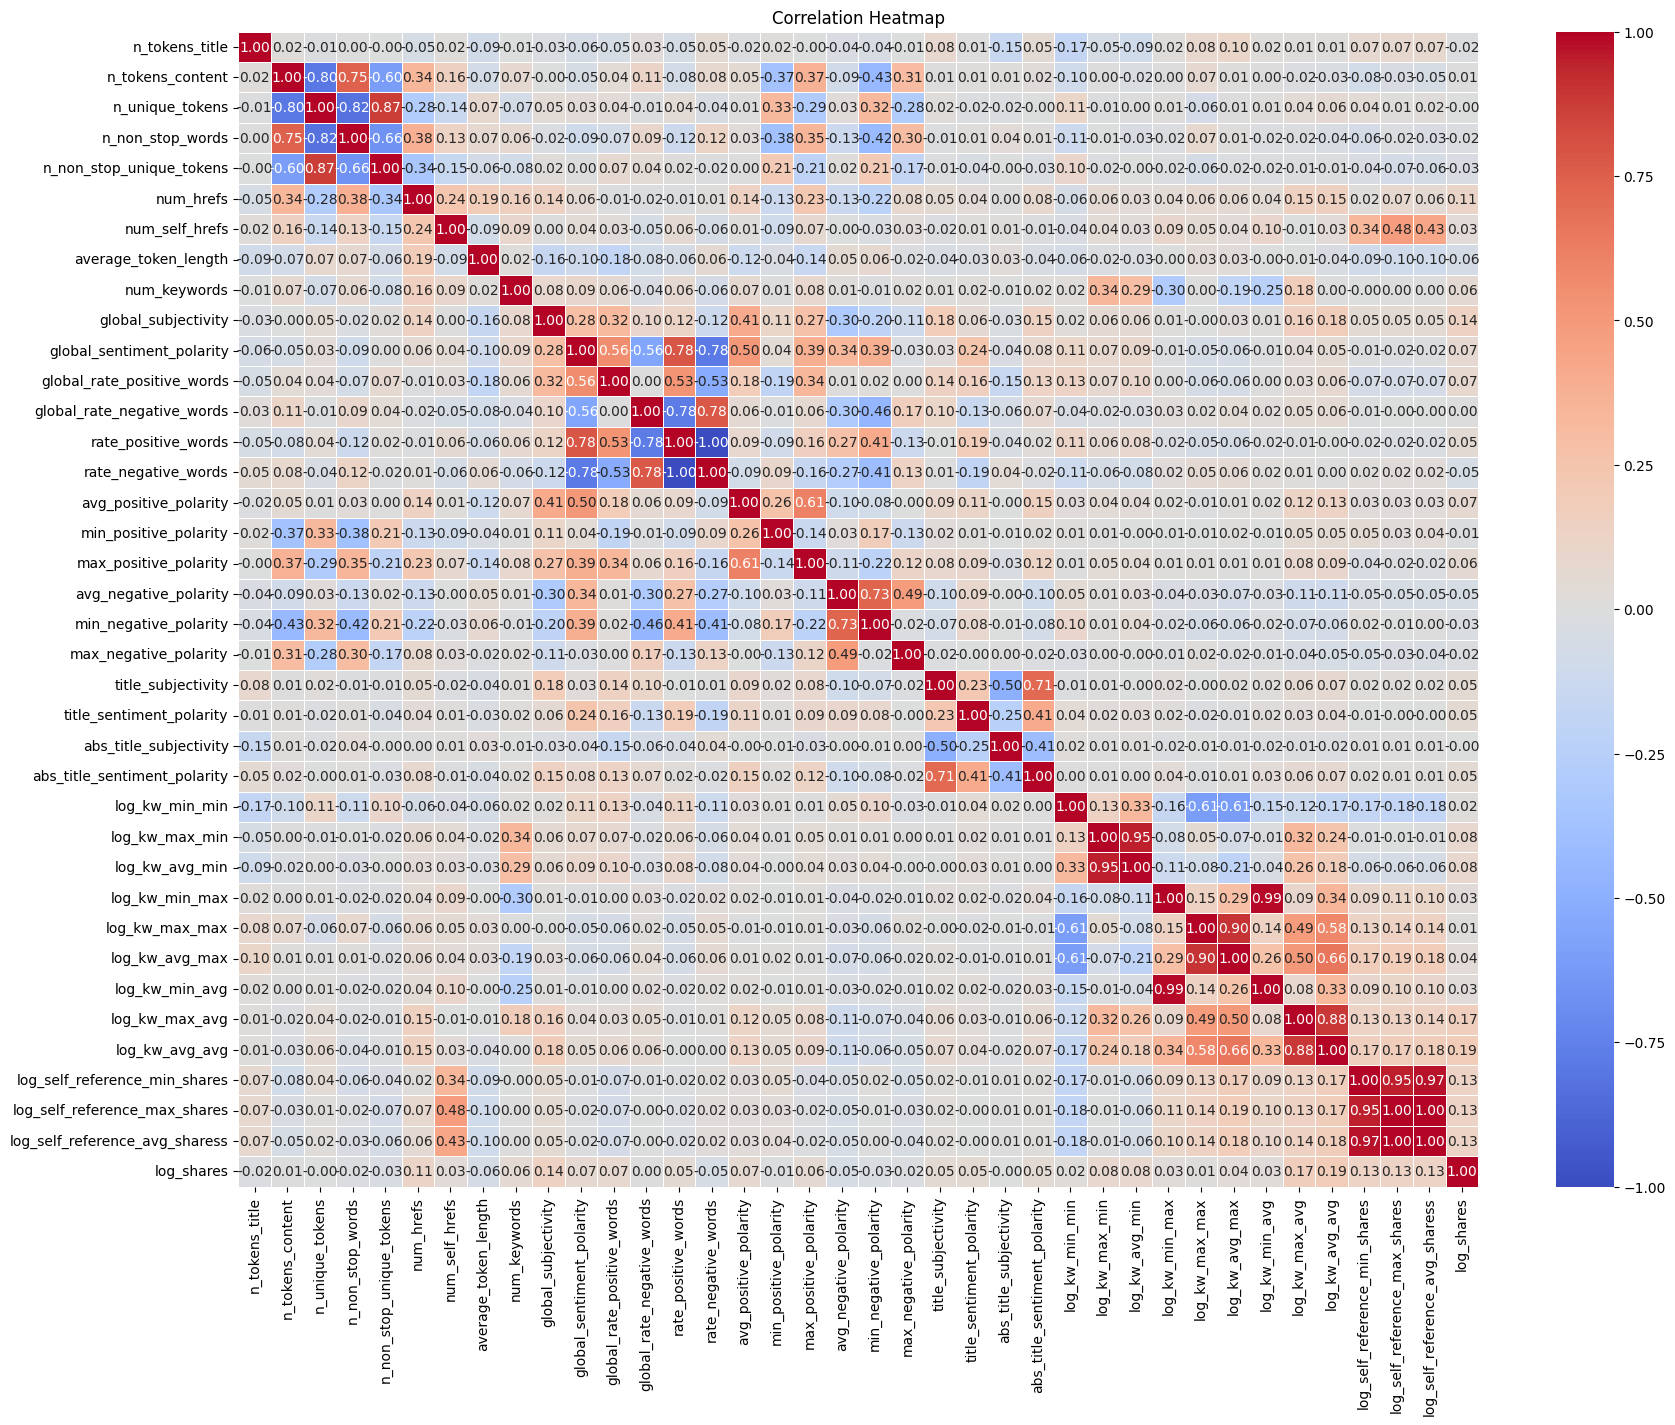

In [9]:
plt.figure(figsize=(20, 15))
correlation_matrix = df[NUMERICAL_FEATURES + [TARGET]].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

From the correlation plot we can see the following:
- All `log_self_reference_*` features are highly correlated. Since all have the same correlation with `shares`, we will keep the average one, given that it is the most interpretable.
- For the keyword features, again, we will only keep the averages for interpretability, in order to reduce correlation.
- We will remove the `abs_*` features for their high correlation with their non-absolute-value version and low correlation with the target.
- Again, we will keep only the `avg_*` polarity features for interpretability over the minimums and maximums.
- Keep only `global_rate_positive_words` and remove all other rate-related features.
- Finally, regarding the token-related features, we will only keep `n_tokens_title` and `n_tokens_content`. The rest are very correlated with these ones and present lower correlation with the target.

In [10]:
# log_self_reference_*
df.rename(columns={"log_self_reference_avg_sharess": "log_avg_shares_reference"}, inplace=True)
df.drop(columns=["log_self_reference_max_shares", "log_self_reference_min_shares"], inplace=True)
NUMERICAL_FEATURES.remove("log_self_reference_max_shares")
NUMERICAL_FEATURES.remove("log_self_reference_min_shares")
NUMERICAL_FEATURES.remove("log_self_reference_avg_sharess")
NUMERICAL_FEATURES.append("log_avg_shares_reference")


# keyword features
df.rename(columns={
    "log_kw_min_avg": "log_avg_shares_min_kw",
    "log_kw_max_avg": "log_avg_shares_max_kw",
}, inplace=True)
NUMERICAL_FEATURES.remove("log_kw_avg_avg")
NUMERICAL_FEATURES.remove("log_kw_min_avg")
NUMERICAL_FEATURES.remove("log_kw_max_avg")
NUMERICAL_FEATURES.append("log_avg_shares_min_kw")
NUMERICAL_FEATURES.append("log_avg_shares_max_kw")
df.drop(columns=[
    "log_kw_avg_avg",
    "log_kw_avg_min",
    "log_kw_avg_max",
    "log_kw_min_min",
    "log_kw_min_max",
    "log_kw_max_min",
    "log_kw_max_max",
], inplace=True)
NUMERICAL_FEATURES = [feature for feature in NUMERICAL_FEATURES if feature not in [
    "log_kw_avg_avg",
    "log_kw_avg_min",
    "log_kw_avg_max",
    "log_kw_min_min",
    "log_kw_min_max",
    "log_kw_max_min",
    "log_kw_max_max",
]]

# abs_*
df.drop(columns=["abs_title_subjectivity", "abs_title_sentiment_polarity"], inplace=True)
NUMERICAL_FEATURES.remove("abs_title_subjectivity")
NUMERICAL_FEATURES.remove("abs_title_sentiment_polarity")

# avg_*
for prefix in ["positive", "negative"]:
    df.drop(columns=[f"min_{prefix}_polarity", f"max_{prefix}_polarity"], inplace=True)
    NUMERICAL_FEATURES = [feature for feature in NUMERICAL_FEATURES if feature not in [f"min_{prefix}_polarity", f"max_{prefix}_polarity"]]

# rate_* and global_rate_negative_words
df.drop(columns=["rate_positive_words", "rate_negative_words", "global_rate_negative_words"], inplace=True)
NUMERICAL_FEATURES.remove("rate_positive_words")
NUMERICAL_FEATURES.remove("rate_negative_words")
NUMERICAL_FEATURES.remove("global_rate_negative_words")

# keep only n_tokens_title and n_tokens_content
for feature in ["n_unique_tokens", "n_non_stop_words", "n_non_stop_unique_tokens"]:
    df.drop(columns=[feature], inplace=True)
    NUMERICAL_FEATURES.remove(feature)

Now, let's check them after the preprocessing.

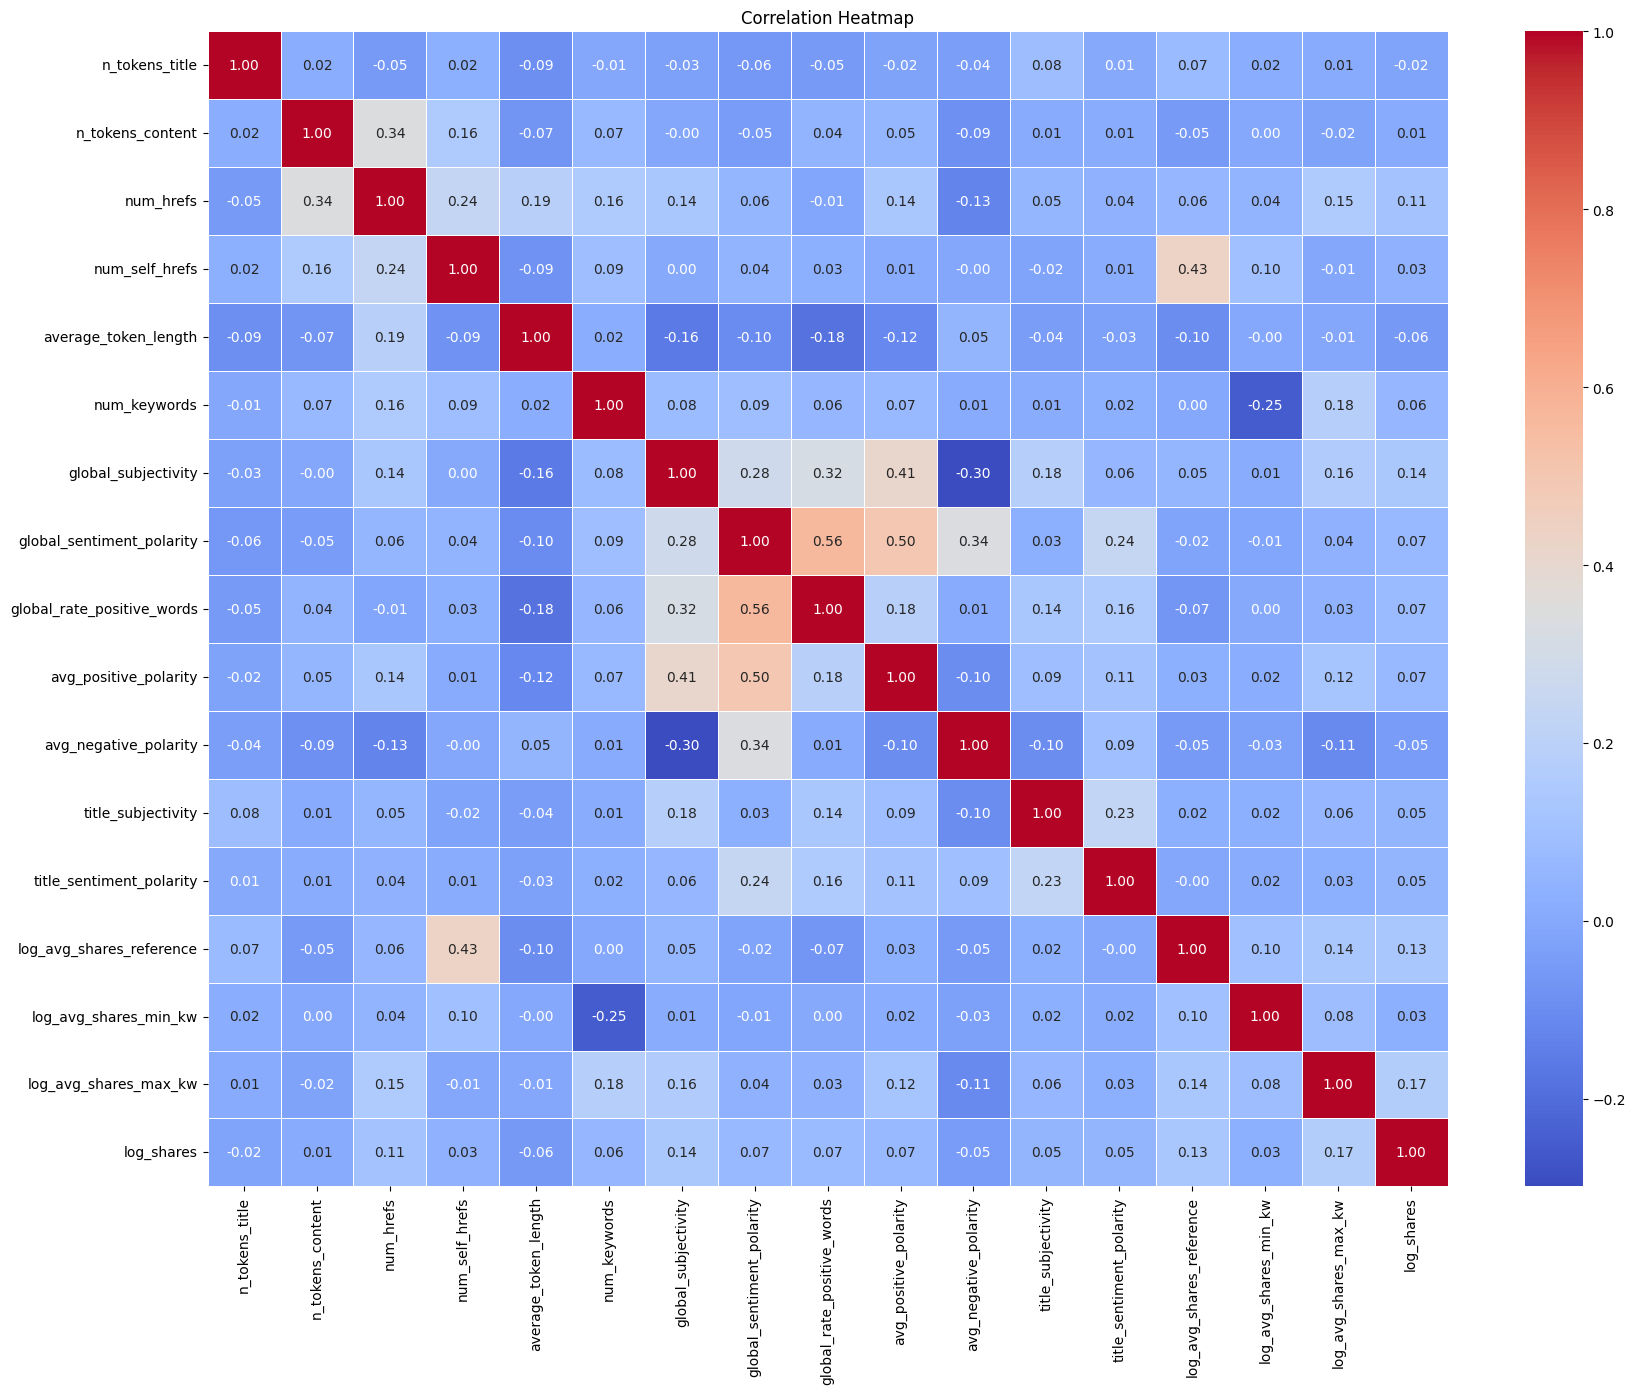

In [11]:
plt.figure(figsize=(20, 15))
correlation_matrix = df[NUMERICAL_FEATURES + [TARGET]].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

We can see that this is clearly a far less correlated feature set than the one we saw before. Additionally, it is much more explainable and interpretable. 

Now, given that we encoded our categorical variables using one-hot encoding and label encoding, we can also see how these correlate to each other.

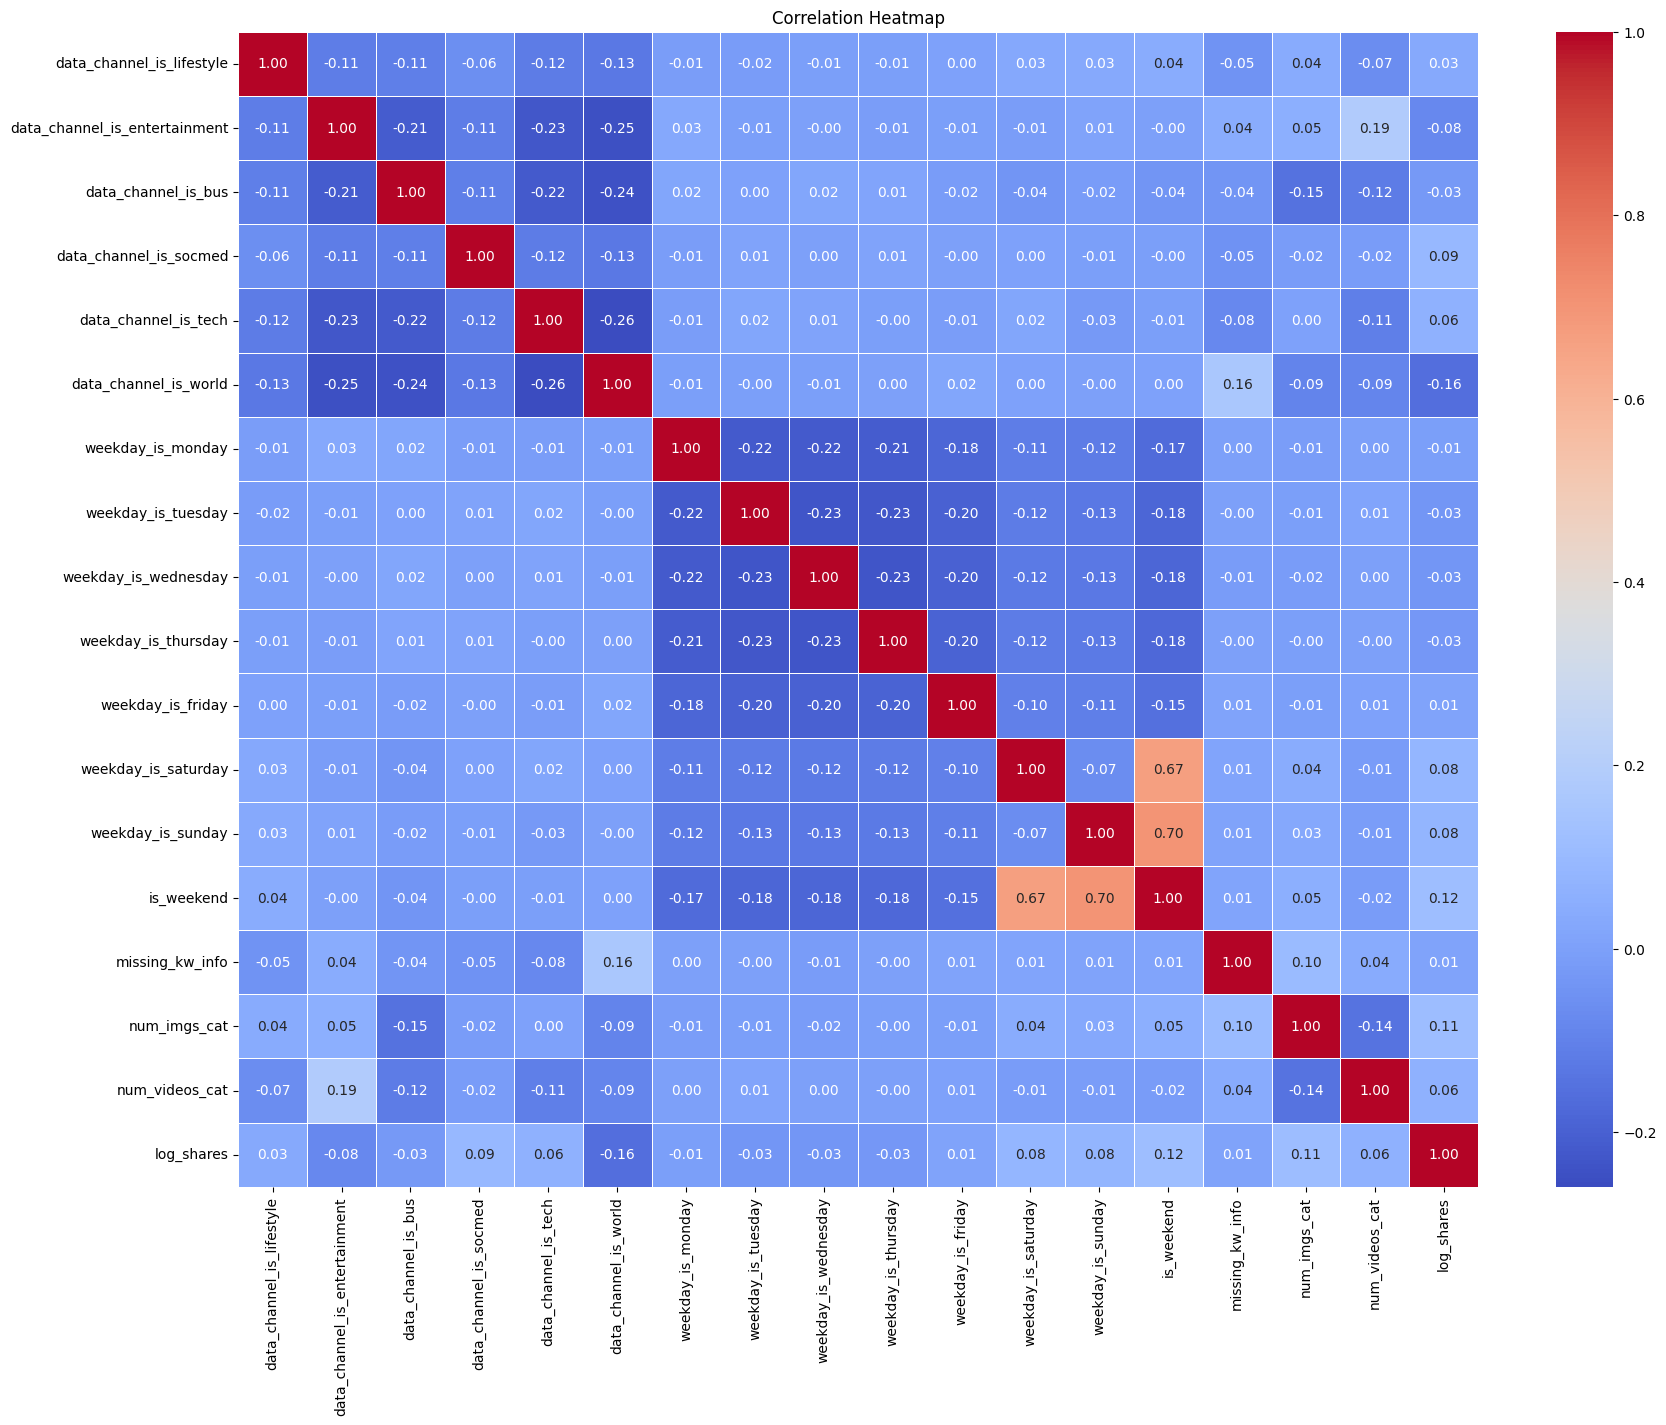

In [12]:
plt.figure(figsize=(20, 15))
correlation_matrix = df[CATEGORICAL_FEATURES + [TARGET]].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

The only important correlation worth noting is the one between `is_weekend` and the individual features for Saturdays and Sundays. We will be removing the individual features and keeping the more general given that it is higher correlated with `shares`.

In [13]:
df.drop(columns=["weekday_is_saturday", "weekday_is_sunday"], inplace=True)
CATEGORICAL_FEATURES.remove("weekday_is_saturday")
CATEGORICAL_FEATURES.remove("weekday_is_sunday")

Finally we will plot the full correlation matrix containing all feeatures.

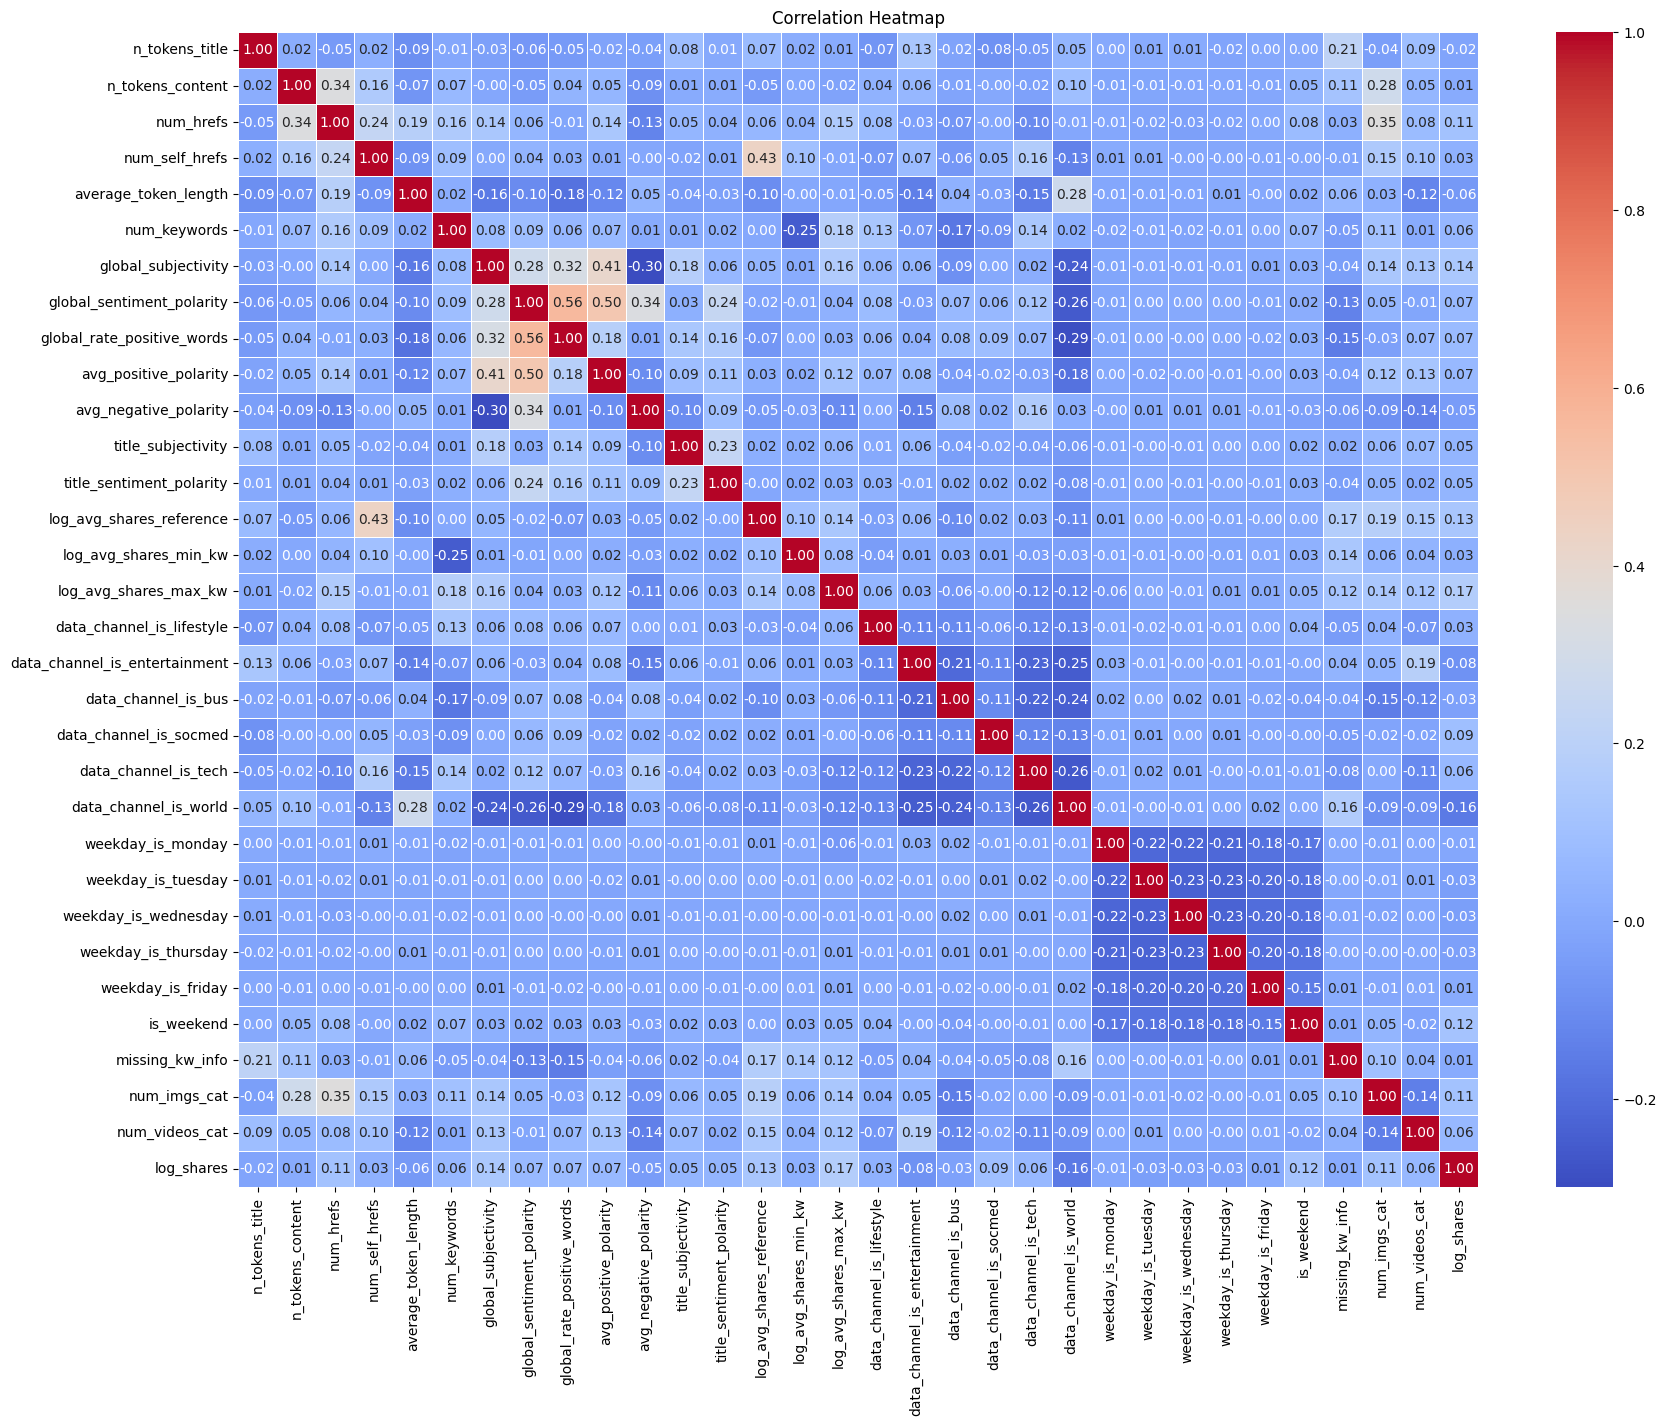

In [14]:
plt.figure(figsize=(20, 15))
correlation_matrix = df[NUMERICAL_FEATURES + CATEGORICAL_FEATURES + [TARGET]].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

As we can see, we have solve the multicollinearity problem while also heavily reducing the redundancy and volume of our data. For the following sections, we will need to take into account that we are working with different scale features, therefore, we will need to use some scaling techniques to deal with that. 

## 2.4 Feature Scaling

As identified during the exploratory data analysis, many of our continuous features showed right-skewed distributions with long tails, which can affect distance-based algorithms like K-Means and PCA, as well as regularized linear models. 

To mitigate this, we will apply a `StandardScaler`to all numercial features:

In [15]:
X = df.drop(columns=[TARGET])
y = df[TARGET]

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

df_preprocessed = pd.concat([X_scaled, y], axis=1)

Lastly, we save our preprocessed data into a new CSV file.

In [16]:
df_preprocessed.to_csv('../data/preprocessed.csv', index=False)